# Setup

This notebook focuses on the 2D propagation equation for LCP and RCP light

$$\frac{\partial E_+}{\partial z} = i \frac{\gamma}{3} (|E_+|^2 + 2 |E_-|^2)E_+$$
$$\frac{\partial E_-}{\partial z} = i \frac{\gamma}{3} (|E_-|^2 + 2 |E_+|^2)E_-$$

In [33]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

P_0 = 30
T_0 = 1e-12

theta = np.pi / 6

beta_2 = 1.882134389196386e-26 # s^2 / m
L_D = T_0 ** 2 / np.abs( beta_2 )
print(f'{L_D=}')

L = 1
print(f'{L=}')

n_2 = 3.2e-20 # m^2 / W
omega_0 = 2 * np.pi * 2.998e8 / 1032e-9
A_eff = 1e-12 # m^2
gamma = n_2 * omega_0 / ( 2.998e8 * A_eff )

print(f'Approximate peak phase change: {P_0 * gamma * np.abs( np.sin(theta) ** 2 - np.cos(theta) ** 2 ) * L:.2f} rad')

N = np.sqrt( gamma * P_0 * T_0 ** 2 / np.abs(beta_2) )
print(f'{N=:.3f}')

L_D=np.float64(53.13116883364367)
L=1
Approximate peak phase change: 2.92 rad
N=17.622


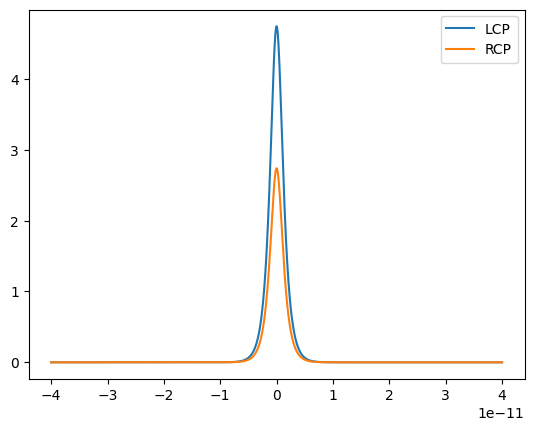

In [34]:
t = np.linspace(-40e-12, 40e-12, 2048)
Z = np.linspace(0, L, 1000)

A_L_0 = np.sqrt(P_0) * np.cos(theta) / np.cosh(t / T_0)
A_R_0 = np.sqrt(P_0) * np.sin(theta) / np.cosh(t / T_0)

plt.plot(t, A_L_0, label='LCP')
plt.plot(t, A_R_0, label='RCP')
plt.legend()
plt.show()

In [35]:
A = np.zeros((Z.size, 2, t.size), dtype=complex)
A[0, 0] = A_L_0
A[0, 1] = A_R_0

dZ = Z[1] - Z[0]

for ind, (A_L, A_R) in enumerate(A[:-1]):
    A[ind + 1, 0] = np.exp(1j * gamma * ( np.abs(A_L) ** 2 + 2 * np.abs(A_R) ** 2 ) * dZ) * A_L
    A[ind + 1, 1] = np.exp(1j * gamma * ( np.abs(A_R) ** 2 + 2 * np.abs(A_L) ** 2 ) * dZ) * A_R

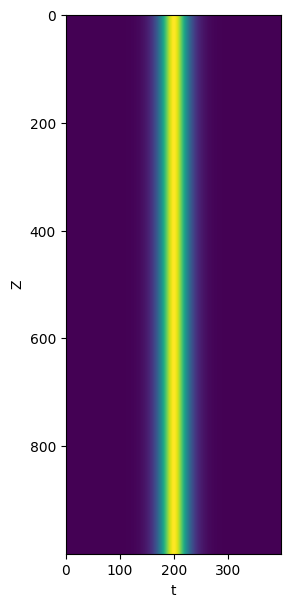

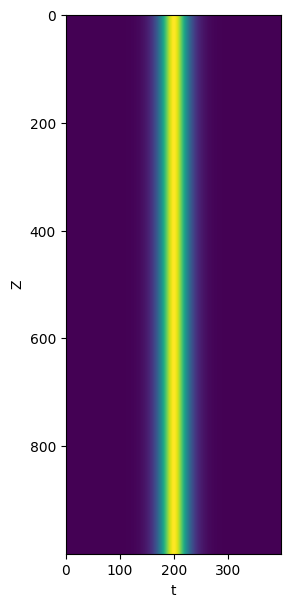

In [36]:
mid = t.size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A[:,0,mid-200:mid+200])**2)
# plt.imshow(np.abs(A_X)**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(np.abs(A[:,1,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

In [8]:
from matplotlib import animation
from matplotlib import patches
from copy import copy

fig, ax = plt.subplots(1, 2, figsize=(10,5))

fig.suptitle(f'Polarization at fiber output (10 m, {P_0:.2f} W)')

start_ind = min(np.argwhere(t > (-10e-12)).flatten())
end_ind = min(np.argwhere(t > (10e-12)).flatten())

LCP = A[-1, 0]
RCP = A[-1, 1]

ax[0].plot(t[start_ind:end_ind], np.abs(LCP[start_ind:end_ind]), 'b', label='LCP')
ax[0].plot(t[start_ind:end_ind], np.abs(RCP[start_ind:end_ind]), 'r:', label='RCP')

ax[0].legend()

ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_aspect('equal')

def animate(ind):
    if ax[1].has_data():
        [ patch.remove() for patch in ax[1].patches ]

    alpha =  RCP[ind] / LCP[ind]
    phi = np.angle( alpha ) * 360 / ( 2 * np.pi )
    ellipse = patches.Ellipse((0,0), 1, np.abs(alpha), angle=phi, color='red', fill=False)

    patch = ax[1].add_patch(ellipse)

    if len(ax[0].lines) > 2:
        ax[0].lines[-1].remove()
        
    ax[0].axvline(t[ind], color='g', lw=0.5)
    return [ patch ]
    
ani = animation.FuncAnimation(fig, animate, frames=range(start_ind, end_ind + 1, 5), interval=1000/24)

plt.close()

from IPython.display import HTML
# ani.save('images/polarization.gif')
HTML(ani.to_jshtml())

# Testing NLSE Solver with Dispersion and Birefringence

In [46]:
import NLSE

A_X = ( A_L_0 + A_R_0 ) / np.sqrt( 2 )
A_Y = -1j * ( A_L_0 - A_R_0 ) / np.sqrt( 2 )

A_test = NLSE.split_step_2d(
                np.array((A_X, A_Y)),
                t,
                Z,
                T_0,
                beta_2,
                diff_beta=1e-15,
                gamma=gamma
            )

LCP_test = ( A_test[:,0] + 1j * A_test[:,1] ) / np.sqrt( 2 )
RCP_test = ( A_test[:,0] - 1j * A_test[:,1] ) / np.sqrt( 2 )

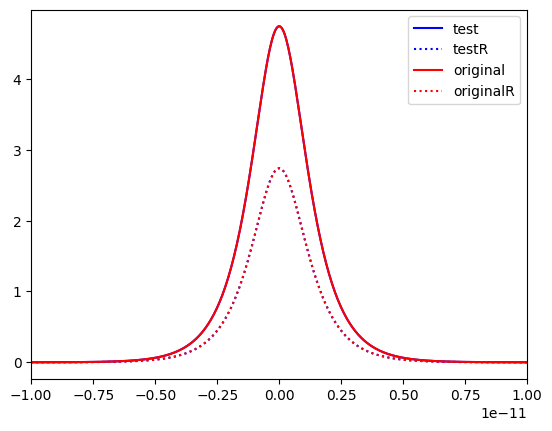

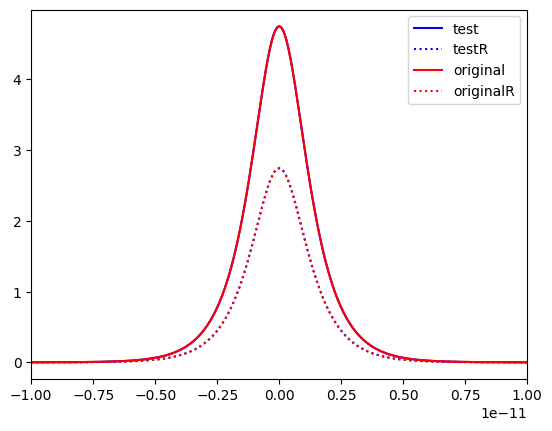

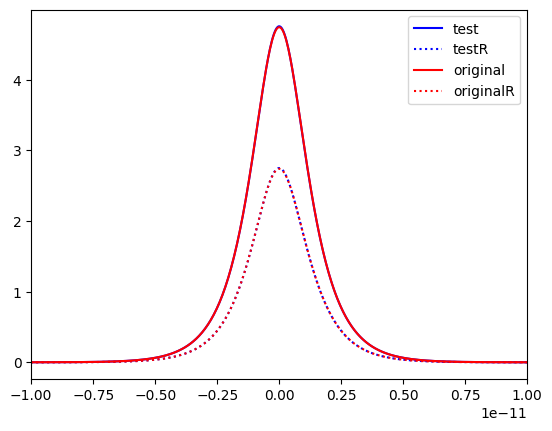

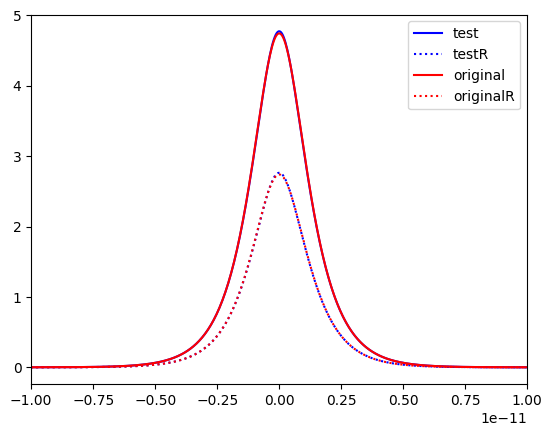

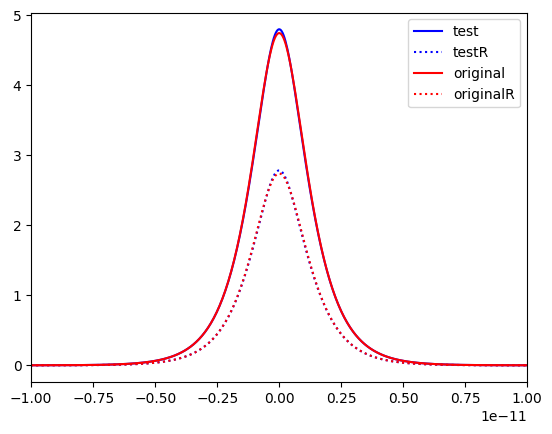

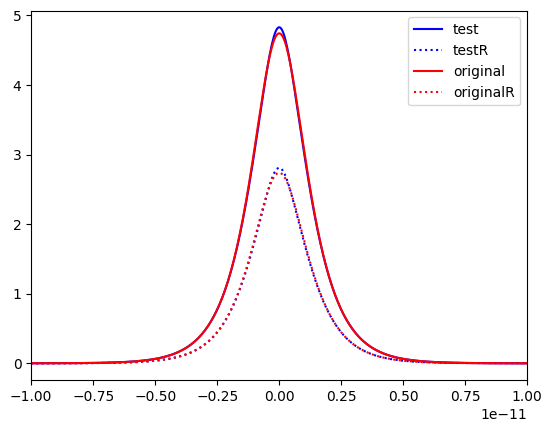

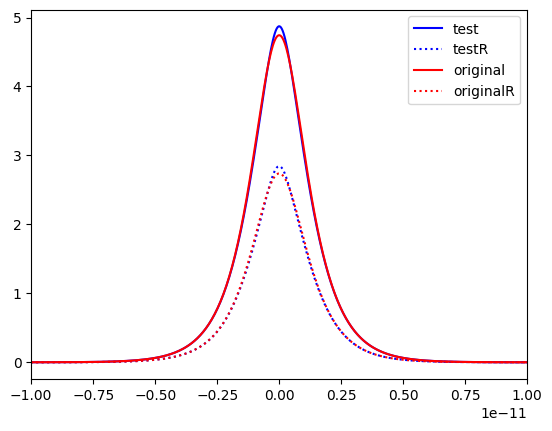

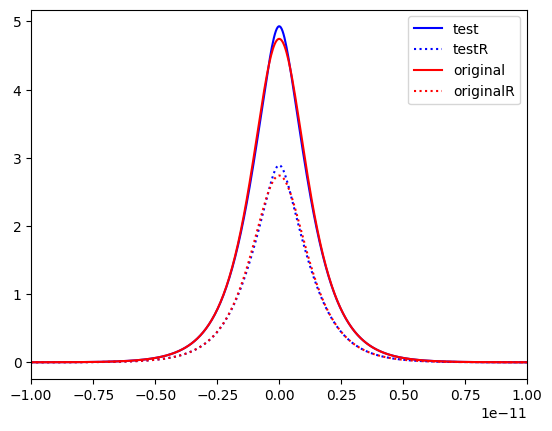

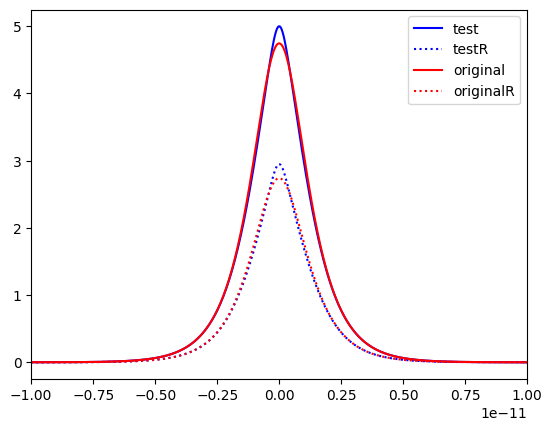

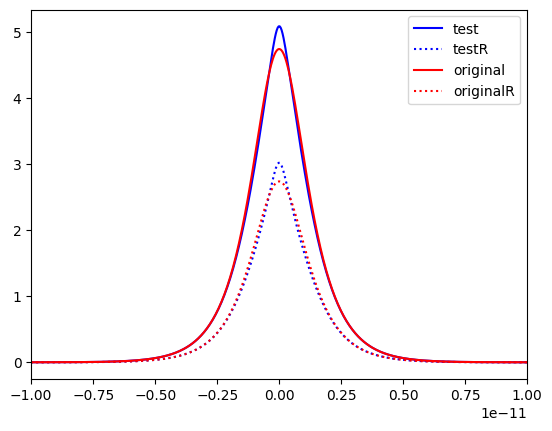

In [47]:
mid = t.size // 2

for i in range(0, LCP_test[:,0].size, 100):
    plt.plot(t, np.abs( LCP_test[i] ), 'b', label='test')
    plt.plot(t, np.abs( RCP_test[i] ), 'b:', label='testR')
    plt.plot(t, np.abs( A[i,0] ), 'r', label='original')
    plt.plot(t, np.abs( A[i,1] ), 'r:',label='originalR')

    plt.xlim(-10e-12,10e-12)

    # alpha_test = RCP_test[i, mid] / LCP_test[i, mid]
    # alpha = A[i,1,mid] / A[i,0,mid]

    # print(np.isclose(alpha,alpha_test),alpha_test,alpha)

    plt.legend()
    plt.show()

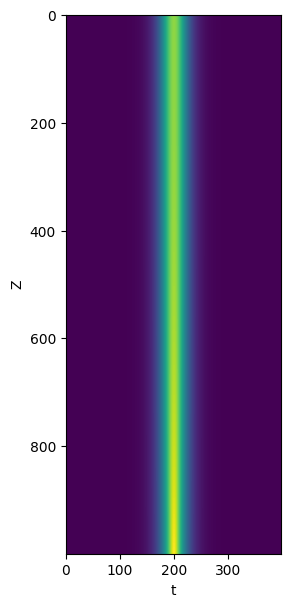

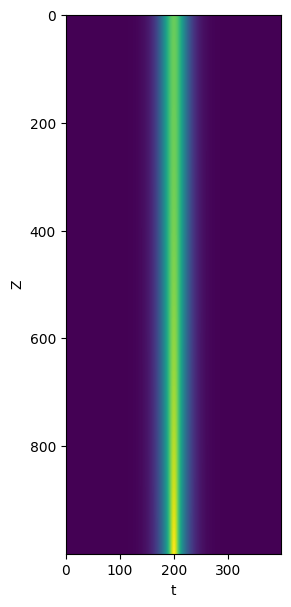

In [45]:
mid = t.size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(LCP_test[:,mid-200:mid+200])**2)
# plt.imshow(np.abs(A_X)**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(np.abs(RCP_test[:,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()